In [137]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [138]:
# Load group data from JSON file
with open('results/full_run_1/simulation_results_groups_1_10.json', 'r') as f:
    results_1_10 = json.load(f)

# Load group data from JSON file
with open('results/full_run_1/simulation_results_groups_21_30.json', 'r') as f:
    results_21_30 = json.load(f)

In [139]:
results_1_10.update(results_21_30)

In [140]:
results = results_1_10

In [141]:
with open('simulation_resources/participant_attitudes.json', 'r') as f:
    participants = json.load(f)

In [142]:
results.keys()

dict_keys(['Group_1_Q1', 'Group_1_Q2A', 'Group_1_Q2B', 'Group_1_Q2C', 'Group_1_Q2D', 'Group_1_Q2E', 'Group_1_Q2F', 'Group_1_Q2G', 'Group_1_Q2H', 'Group_1_Q2I', 'Group_1_Q3A', 'Group_1_Q3B', 'Group_1_Q3C', 'Group_1_Q3D', 'Group_1_Q3E', 'Group_1_Q3F', 'Group_1_Q3G', 'Group_1_Q3H', 'Group_1_Q4A', 'Group_1_Q4B', 'Group_1_Q4C', 'Group_1_Q4D', 'Group_1_Q4E', 'Group_1_Q4F', 'Group_1_Q4G', 'Group_1_Q4H', 'Group_1_Q4I', 'Group_1_Q4J', 'Group_1_Q5A', 'Group_1_Q5B', 'Group_1_Q5C', 'Group_1_Q5D', 'Group_1_Q5E', 'Group_1_Q5F', 'Group_1_Q5G', 'Group_1_Q5H', 'Group_1_Q5I', 'Group_1_Q5J', 'Group_1_Q6A', 'Group_1_Q6B', 'Group_1_Q6C', 'Group_1_Q6D', 'Group_1_Q6E', 'Group_1_Q6F', 'Group_1_Q6G', 'Group_1_Q6H', 'Group_1_Q6I', 'Group_1_Q6J', 'Group_4_Q1', 'Group_4_Q2A', 'Group_4_Q2B', 'Group_4_Q2C', 'Group_4_Q2D', 'Group_4_Q2E', 'Group_4_Q2F', 'Group_4_Q2G', 'Group_4_Q2H', 'Group_4_Q2I', 'Group_4_Q3A', 'Group_4_Q3B', 'Group_4_Q3C', 'Group_4_Q3D', 'Group_4_Q3E', 'Group_4_Q3F', 'Group_4_Q3G', 'Group_4_Q3H', '

In [143]:
groups = list(set([int(x.split("_")[1]) for x in results.keys()]))

In [144]:
df = []
for participant in participants:
    pid = participant['id']
    groupid = participant['group']
    if groupid in groups:
        for question in participant['questions'].keys():
            row = {}
            row['id'] = pid
            row["question"] = question
            row["before_attitude"] = participant['questions'][question]
            groupIndex = "Group_" + str(groupid) + "_" + question
            row["after_attitude"] = results[groupIndex]['rankings'][str(pid)]
            df.append(row)

In [145]:
df = pd.DataFrame(df)

In [146]:
question_df = pd.read_csv("clean_data/question_level_master_dataset.csv")

In [147]:
question_df.shape

(25104, 16)

In [148]:
compare_df = df.merge(question_df, left_on=["id","question"], right_on=['ID',"Question"], how="left")

In [149]:
compare_df.shape

(10080, 20)

In [150]:
compare_df.drop(columns=["id","question","before_attitude","BeforeResponse","AfterResponse"], inplace=True)

In [151]:
compare_df.rename(columns={"after_attitude":"LLMNumber"}, inplace=True)

In [152]:
compare_df

,LLMNumber,ID,Question,QuestionText,Topic,ValidResponse,BeforeNumber,AfterNumber,GROUP,RACE,AGEBRACKET,EDUCATION,PARTYBEFORE,GENDER,AGE
0,6.0,0,Q1,How poorly or well would you say the system of...,Democracy,True,5,9,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
1,2.0,0,Q2A,[Reduce the number of refuges allowed to reset...,Immigration,True,0,2,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
2,10.0,0,Q2B,[Increase personnel to process asylum seekers'...,Immigration,True,10,10,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
3,0.0,0,Q2C,[Provide aid to reduce poverty and violence in...,Immigration,True,0,7,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
4,5.0,0,Q2D,[Increase the number of visas for skilled work...,Immigration,True,5,10,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10075,6.0,522,Q6F,[The US should recommit to the Iran Nuclear Ag...,Global Position,True,5,5,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45
10076,10.0,522,Q6G,[Presidents should be required to obtain expli...,Global Position,True,10,5,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45
10077,9.0,522,Q6H,[The U.S. should intervene abroad when it is n...,Global Position,True,10,10,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45
10078,4.0,522,Q6I,[The U.S. should increase military spending by...,Global Position,True,3,0,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45


In [153]:
compare_df["ABS_DIFF"] = abs(compare_df["LLMNumber"] - compare_df["AfterNumber"])
compare_df["DIFF"] = (compare_df["LLMNumber"] - compare_df["AfterNumber"])

In [154]:
acceptable_range = list(range(0,11))

In [155]:
# filter out rows where LLMNumber, BeforeNumber, or AfterNumber is 77 98 or 99
compare_df = compare_df[compare_df["LLMNumber"].isin(acceptable_range)]
compare_df = compare_df[compare_df["AfterNumber"].isin(acceptable_range)]
compare_df = compare_df[compare_df["BeforeNumber"].isin(acceptable_range)]

In [156]:
compare_df.shape

(9182, 17)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

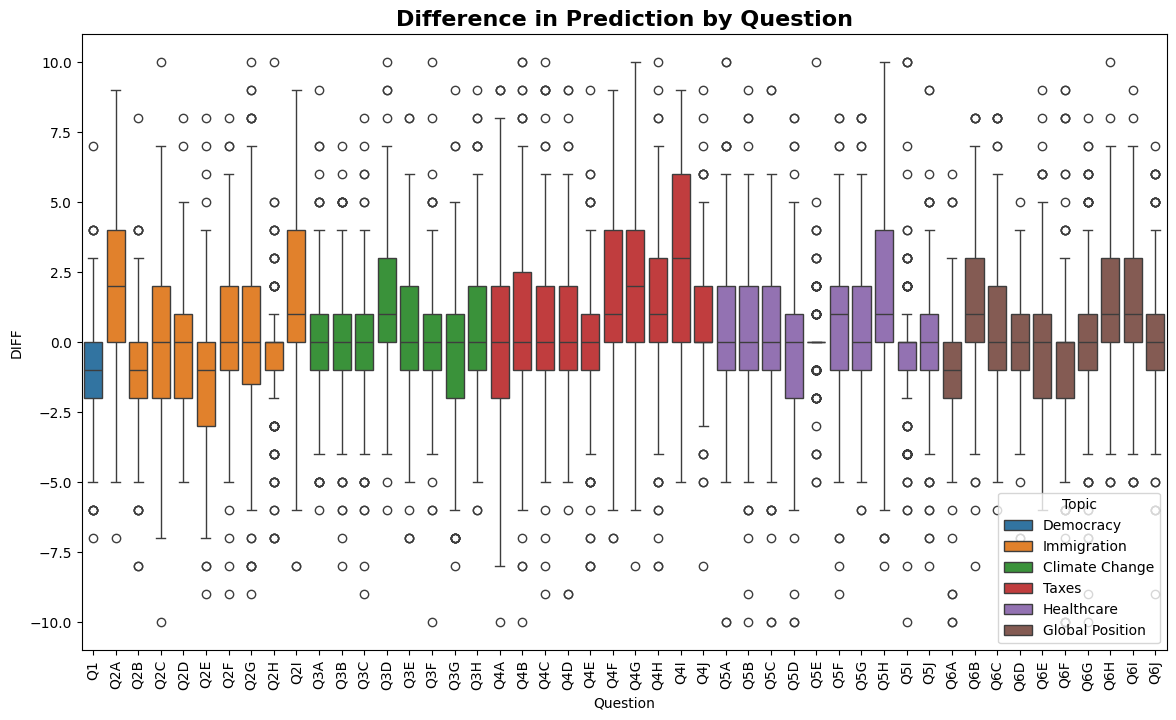

In [157]:
fig = plt.figure(figsize=(14, 8))
sns.boxplot(data=compare_df, x='Question', y='DIFF', hue='Topic')
plt.title('Difference in Prediction by Question', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)

In [158]:
compare_df[compare_df["DIFF"] > 10]

,LLMNumber,ID,Question,QuestionText,Topic,ValidResponse,BeforeNumber,AfterNumber,GROUP,RACE,AGEBRACKET,EDUCATION,PARTYBEFORE,GENDER,AGE,ABS_DIFF,DIFF


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_2759/1155802422.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


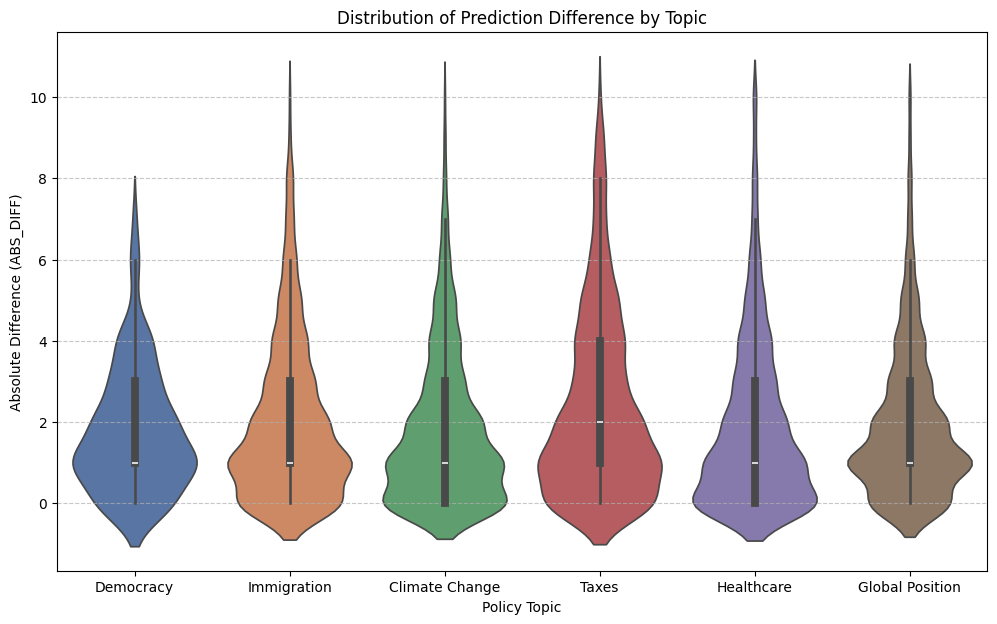

In [160]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='ABS_DIFF',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic')
plt.xlabel('Policy Topic')
plt.ylabel('Absolute Difference (ABS_DIFF)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_2759/878779666.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


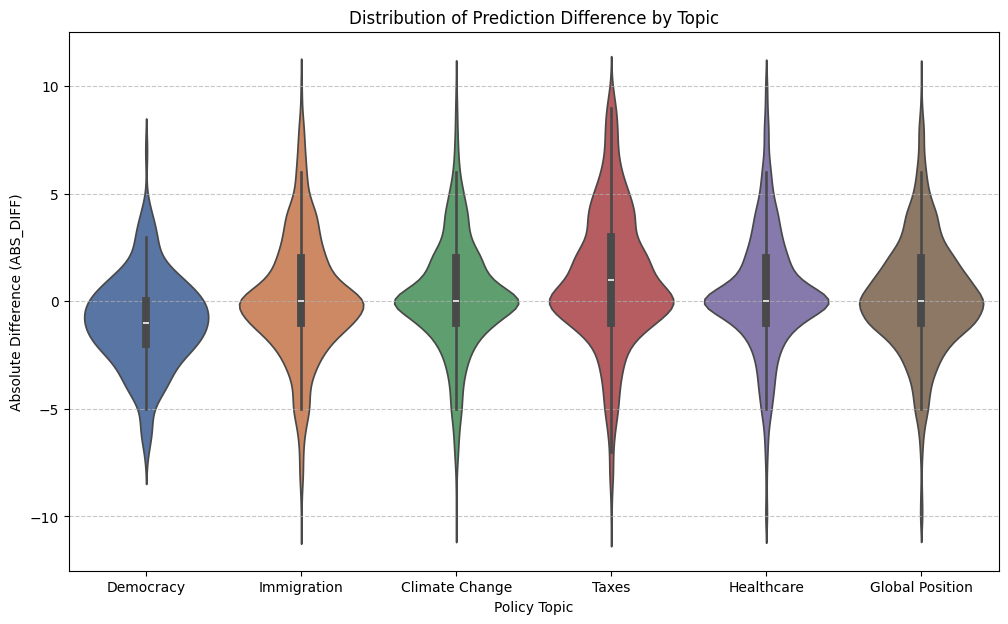

In [161]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='DIFF',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic')
plt.xlabel('Policy Topic')
plt.ylabel('Absolute Difference (ABS_DIFF)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

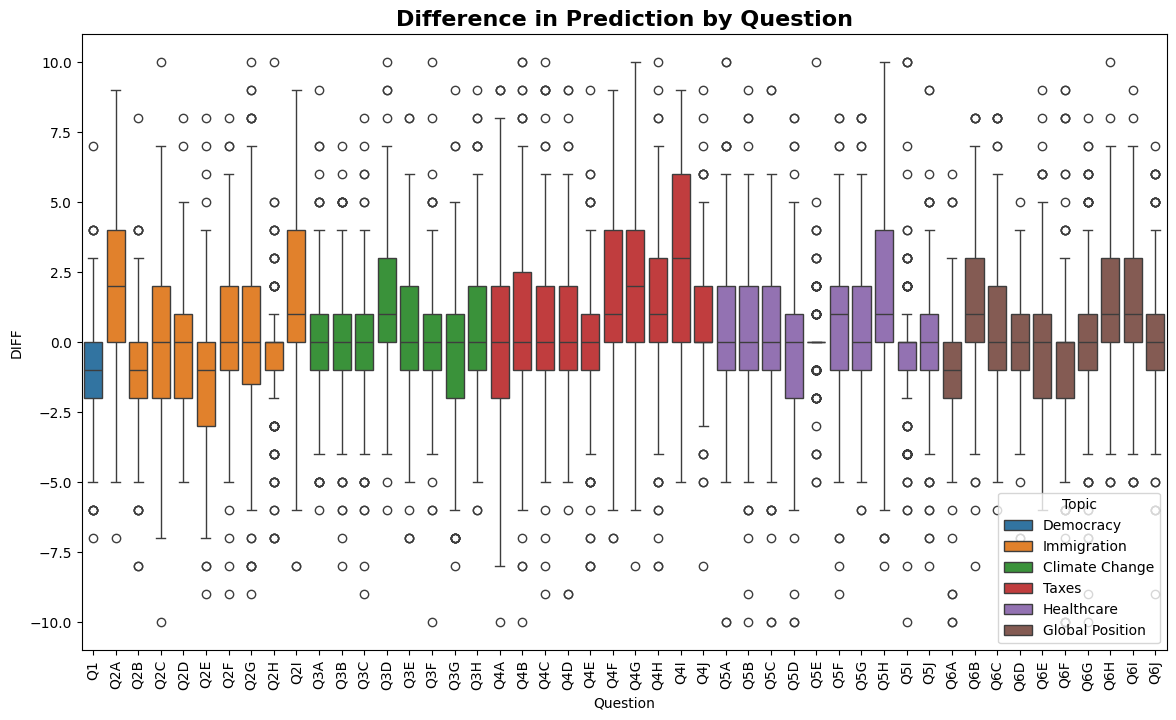

In [162]:
fig = plt.figure(figsize=(14, 8))
sns.boxplot(data=compare_df, x='Question', y='DIFF', hue='Topic')
plt.title('Difference in Prediction by Question', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)

In [163]:
! pip install scipy


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [169]:
import pandas as pd
from scipy.stats import chi2_contingency

# Assume 'df' is your DataFrame
stats_df = []
for question in compare_df['Question'].unique():
    # Filter the data for a specific question
    row = {}
    question_data = compare_df[compare_df['Question'] == question]

    # ... proceed with the test on question_data ...

    # Create a contingency table
    contingency_table = pd.crosstab(question_data['LLMNumber'], question_data['AfterNumber'])

    # Perform the Chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Interpret the result
    alpha = 0.05
    row['Question'] = question
    row['QuestionText'] = question_data['QuestionText'].iloc[0]
    row['p_value'] = p_value
    if p_value < alpha:
        row['Significant'] = True
        #print("Same")
        #print("Result: Statistically significant relationship found. (Reject the null hypothesis of independence)")
    else:
        row['Significant'] = False
        #print("Different")
        #print("Result: No significant relationship found. (Fail to reject the null hypothesis of independence)")
    stats_df.append(row)
stats_df = pd.DataFrame(stats_df)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

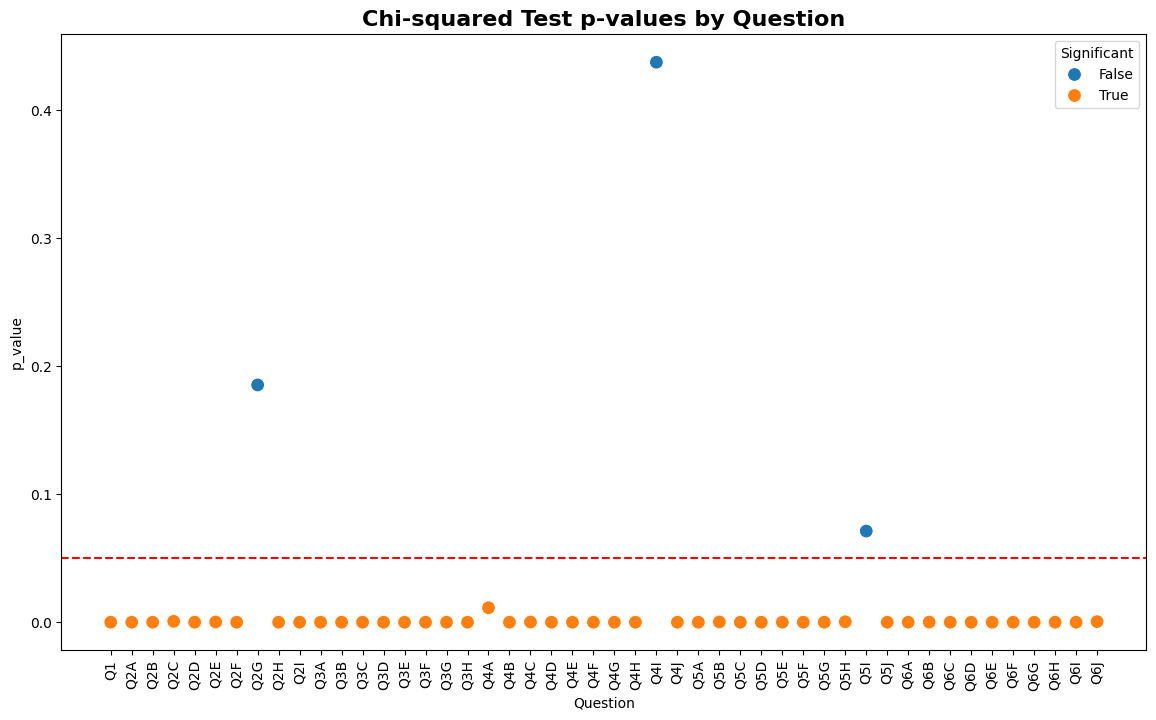

In [165]:
# plot p_values vs Questions with line at 0.05
fig = plt.figure(figsize=(14, 8))
sns.scatterplot(data=stats_df, x='Question', y='p_value', hue='Significant', s=100)
plt.axhline(0.05, color='red', linestyle='--')
plt.title('Chi-squared Test p-values by Question', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)

In [176]:
# get all unique EDUCATION in participants
set_education = []
for participant in participants:
    set_education.append(participant["demographics"]["EDUCATION"])
set_education = set(set_education)

In [177]:
set_education

{'BA or above', 'HS graduate or equivalent', 'No HS diploma', 'Some college'}

In [170]:
stats_df.to_csv("results/full_run_1/chi_squared_results.csv", index=False)

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_2759/1860688694.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data_full, x='DIFF', y='counts', palette='viridis')


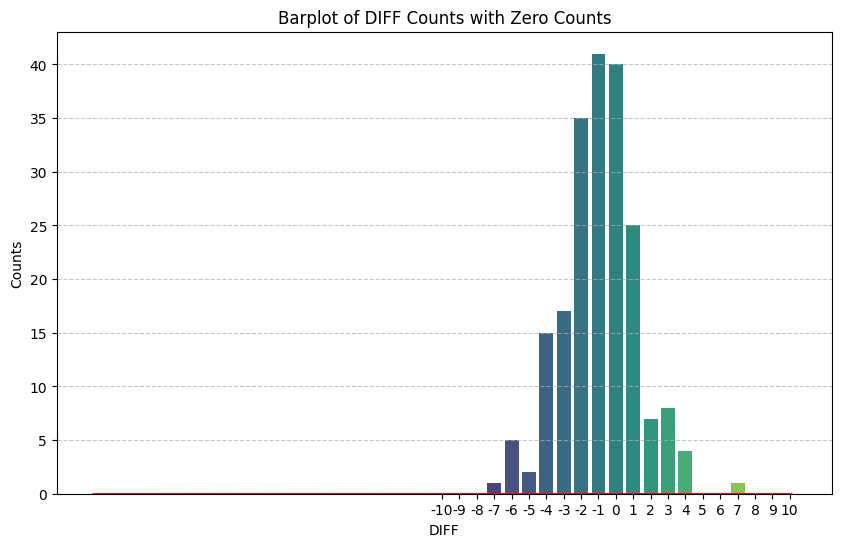

In [208]:
compare_df_Q1 = compare_df[compare_df["Question"] == "Q1"]
# create barplot with  DIFF for Q1
plt.figure(figsize=(10, 6))
counts_df = compare_df_Q1.groupby("DIFF").size().reset_index(name='counts')
# i also want to have x ticks from -10 to 10


full_range = pd.DataFrame({'DIFF': np.arange(-10, 11, 1)})
plot_data_full = full_range.merge(counts_df, on='DIFF', how='left').fillna(0)
# Create the barplot using the data that includes zero counts
sns.barplot(data=plot_data_full, x='DIFF', y='counts', palette='viridis')
plt.title('Barplot of DIFF Counts with Zero Counts')
plt.xlabel('DIFF')
plt.ylabel('Counts')
sns.kdeplot(data=counts_df, x='DIFF', color='red', bw_adjust=1, fill=True, alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.7)


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_2759/609076782.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=compare_df_Q1, x='DIFF', bins=21, palette='viridis', kde=True, shrink=0.9)


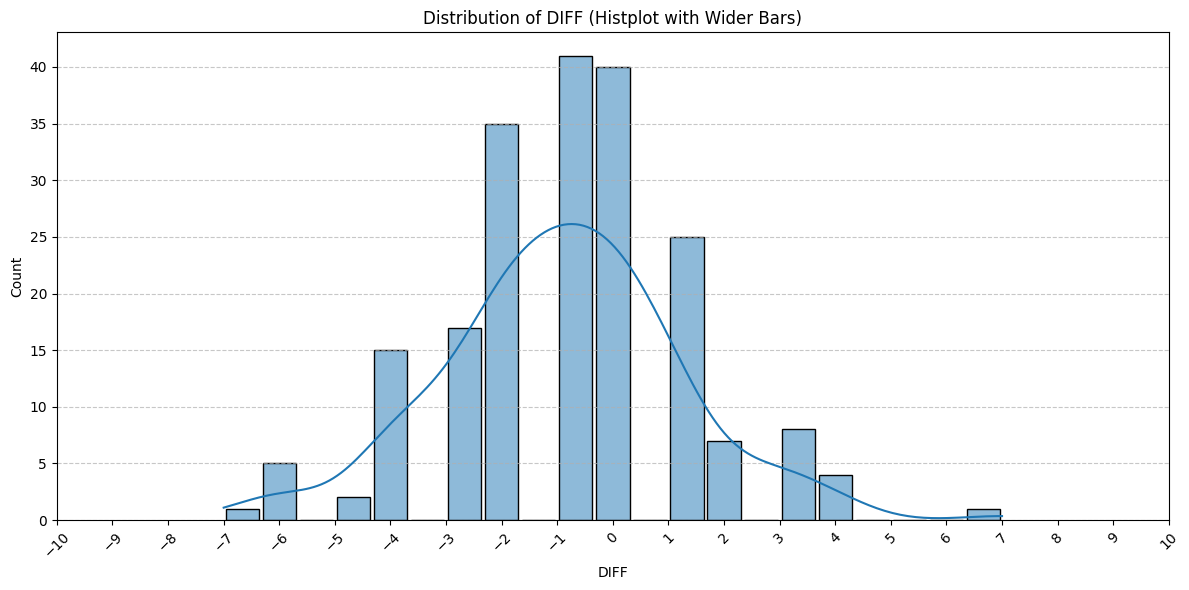

In [205]:
plt.figure(figsize=(12, 6))

# Added shrink=0.9 to increase the bar width
sns.histplot(data=compare_df_Q1, x='DIFF', bins=21, palette='viridis', kde=True, shrink=0.9)

plt.xticks(np.arange(-10, 11, 1), rotation=45)
plt.title('Distribution of DIFF (Histplot with Wider Bars)')
plt.xlabel('DIFF')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_2759/2185813697.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=compare_df_Q1, x='DIFF', bins=bin_edges, palette='viridis', kde=True , shrink=0.9)


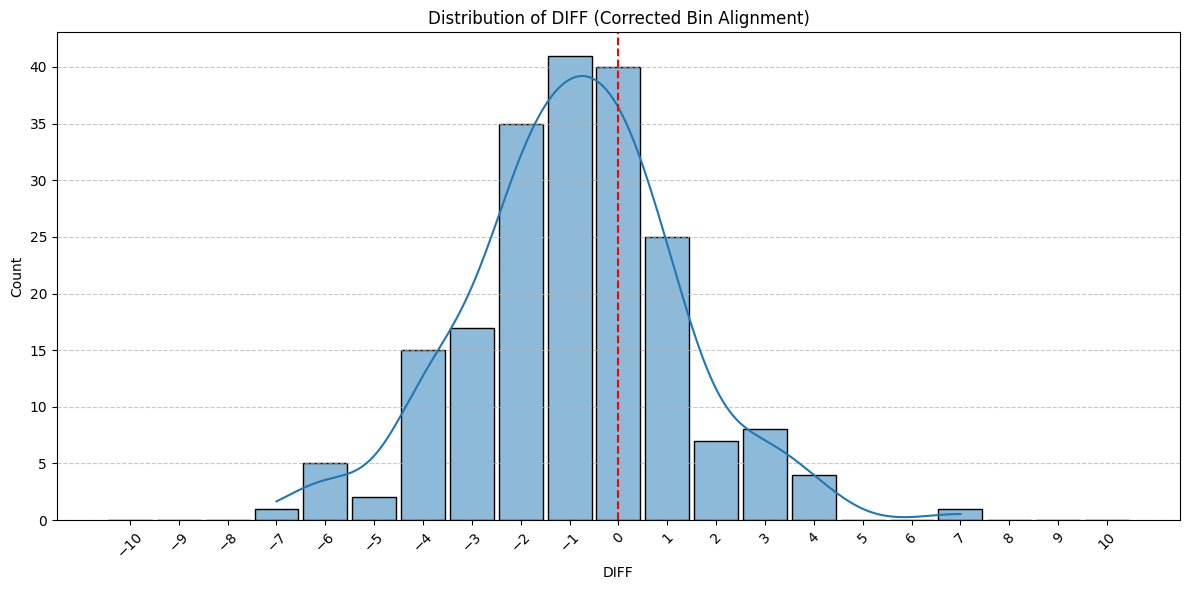

In [215]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create explicit bin edges to ensure perfect centering on the integers
bin_edges = np.arange(-10.5, 11.5, 1)

plt.figure(figsize=(12, 6))

# Use the explicit bin edges (bin_edges) in the histplot
# change color of kde line to red
sns.histplot(data=compare_df_Q1, x='DIFF', bins=bin_edges, palette='viridis', kde=True , shrink=0.9)

# The plt.xticks call remains, and now correctly aligns with the bin centers
plt.xticks(np.arange(-10, 11, 1), rotation=45)
plt.title('Distribution of DIFF (Corrected Bin Alignment)')
plt.xlabel('DIFF')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plot red dotted line at x=0
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()

In [220]:
compare_df_Q1.columns

Index(['LLMNumber', 'ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'AfterNumber', 'GROUP', 'RACE', 'AGEBRACKET',
       'EDUCATION', 'PARTYBEFORE', 'GENDER', 'AGE', 'ABS_DIFF', 'DIFF'],
      dtype='object')

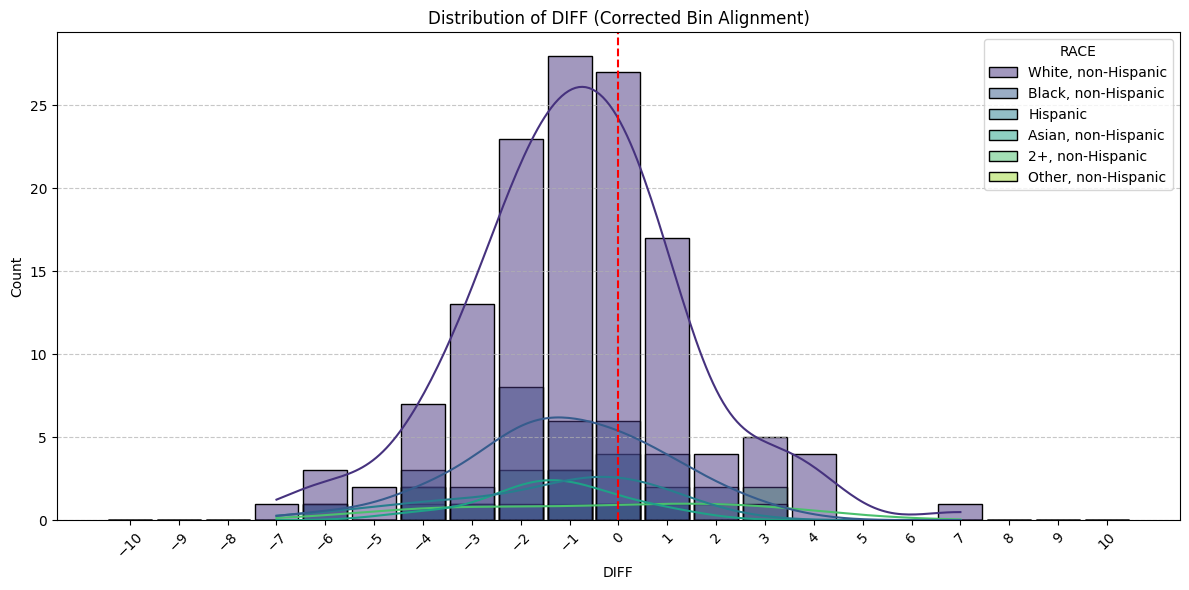

In [218]:
# Create explicit bin edges to ensure perfect centering on the integers
bin_edges = np.arange(-10.5, 11.5, 1)

plt.figure(figsize=(12, 6))

# Use the explicit bin edges (bin_edges) in the histplot
# change color of kde line to red
sns.histplot(data=compare_df_Q1, x='DIFF', hue="RACE", bins=bin_edges, palette='viridis', kde=True , shrink=0.9)

# The plt.xticks call remains, and now correctly aligns with the bin centers
plt.xticks(np.arange(-10, 11, 1), rotation=45)
plt.title('Distribution of DIFF (RACE)')
plt.xlabel('DIFF')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plot red dotted line at x=0
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()

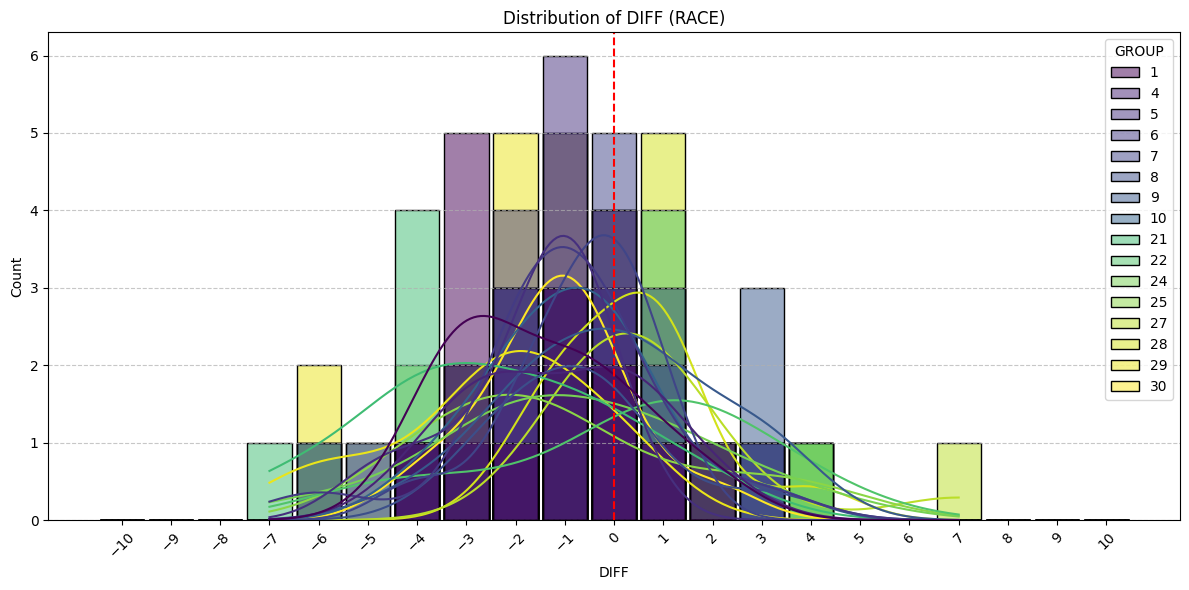

In [219]:
# Create explicit bin edges to ensure perfect centering on the integers
bin_edges = np.arange(-10.5, 11.5, 1)

plt.figure(figsize=(12, 6))

# Use the explicit bin edges (bin_edges) in the histplot
# change color of kde line to red
sns.histplot(data=compare_df_Q1, x='DIFF', hue="GROUP", bins=bin_edges, palette='viridis', kde=True , shrink=0.9)

# The plt.xticks call remains, and now correctly aligns with the bin centers
plt.xticks(np.arange(-10, 11, 1), rotation=45)
plt.title('Distribution of DIFF (GROUP)')
plt.xlabel('DIFF')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plot red dotted line at x=0
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()

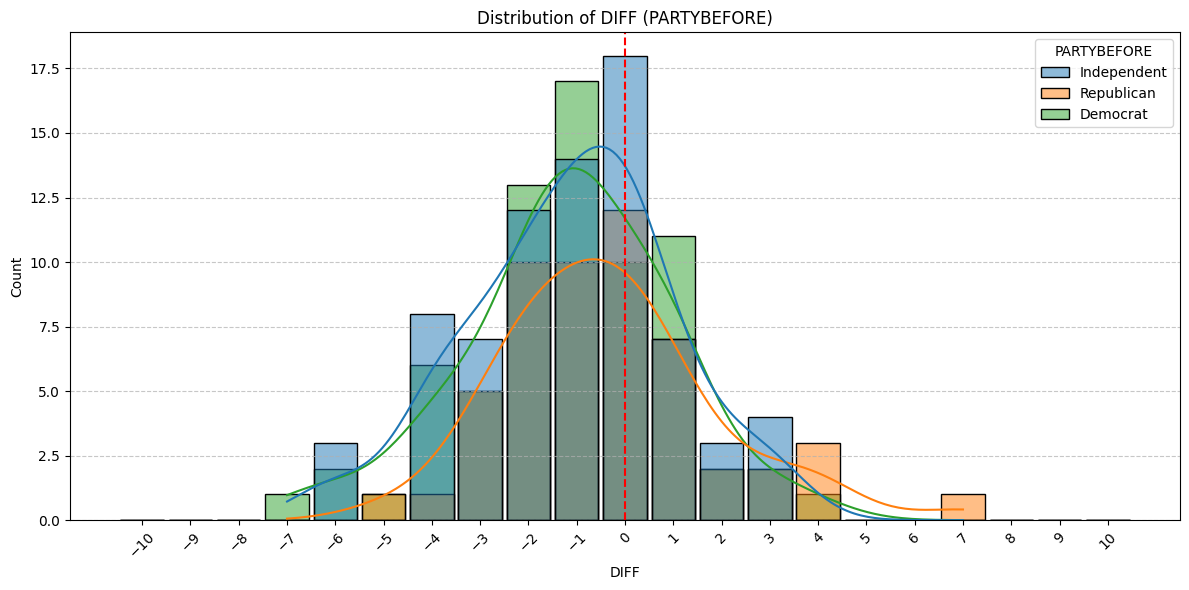

In [223]:
# Create explicit bin edges to ensure perfect centering on the integers
bin_edges = np.arange(-10.5, 11.5, 1)

plt.figure(figsize=(12, 6))

# Use the explicit bin edges (bin_edges) in the histplot
# change color of kde line to red
sns.histplot(data=compare_df_Q1, x='DIFF', hue="PARTYBEFORE", bins=bin_edges, kde=True , shrink=0.9)

# The plt.xticks call remains, and now correctly aligns with the bin centers
plt.xticks(np.arange(-10, 11, 1), rotation=45)
plt.title('Distribution of DIFF (PARTYBEFORE)')
plt.xlabel('DIFF')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plot red dotted line at x=0
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()

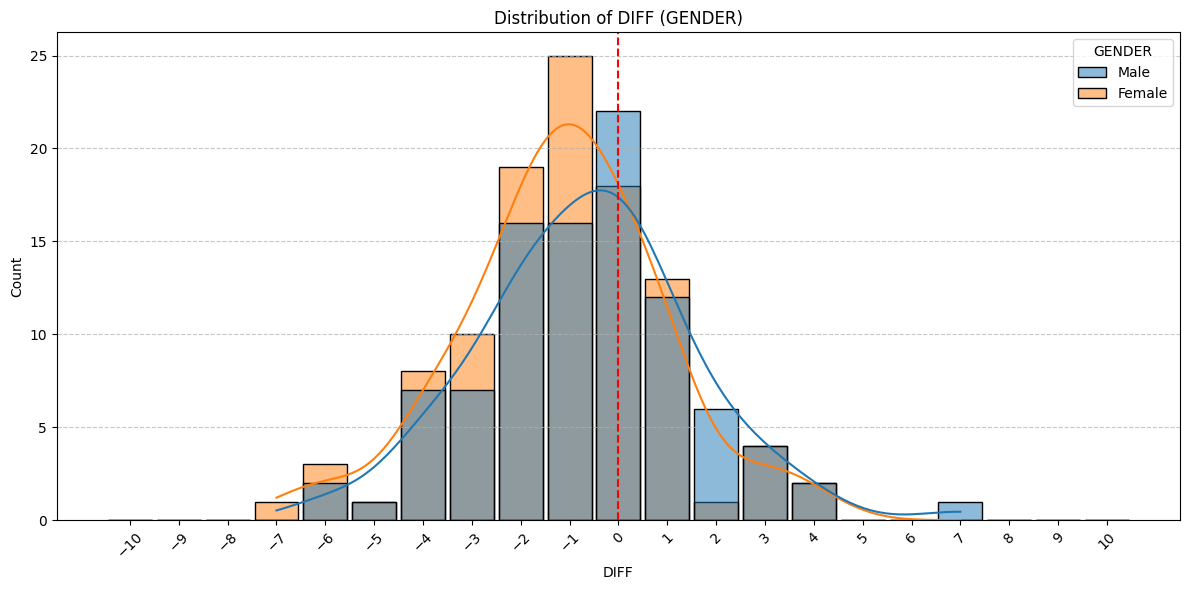

In [224]:
# Create explicit bin edges to ensure perfect centering on the integers
bin_edges = np.arange(-10.5, 11.5, 1)

plt.figure(figsize=(12, 6))

# Use the explicit bin edges (bin_edges) in the histplot
# change color of kde line to red
sns.histplot(data=compare_df_Q1, x='DIFF', hue="GENDER", bins=bin_edges, kde=True , shrink=0.9)

# The plt.xticks call remains, and now correctly aligns with the bin centers
plt.xticks(np.arange(-10, 11, 1), rotation=45)
plt.title('Distribution of DIFF (GENDER)')
plt.xlabel('DIFF')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plot red dotted line at x=0
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()

In [226]:
compare_df_Q1.columns

Index(['LLMNumber', 'ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'AfterNumber', 'GROUP', 'RACE', 'AGEBRACKET',
       'EDUCATION', 'PARTYBEFORE', 'GENDER', 'AGE', 'ABS_DIFF', 'DIFF'],
      dtype='object')

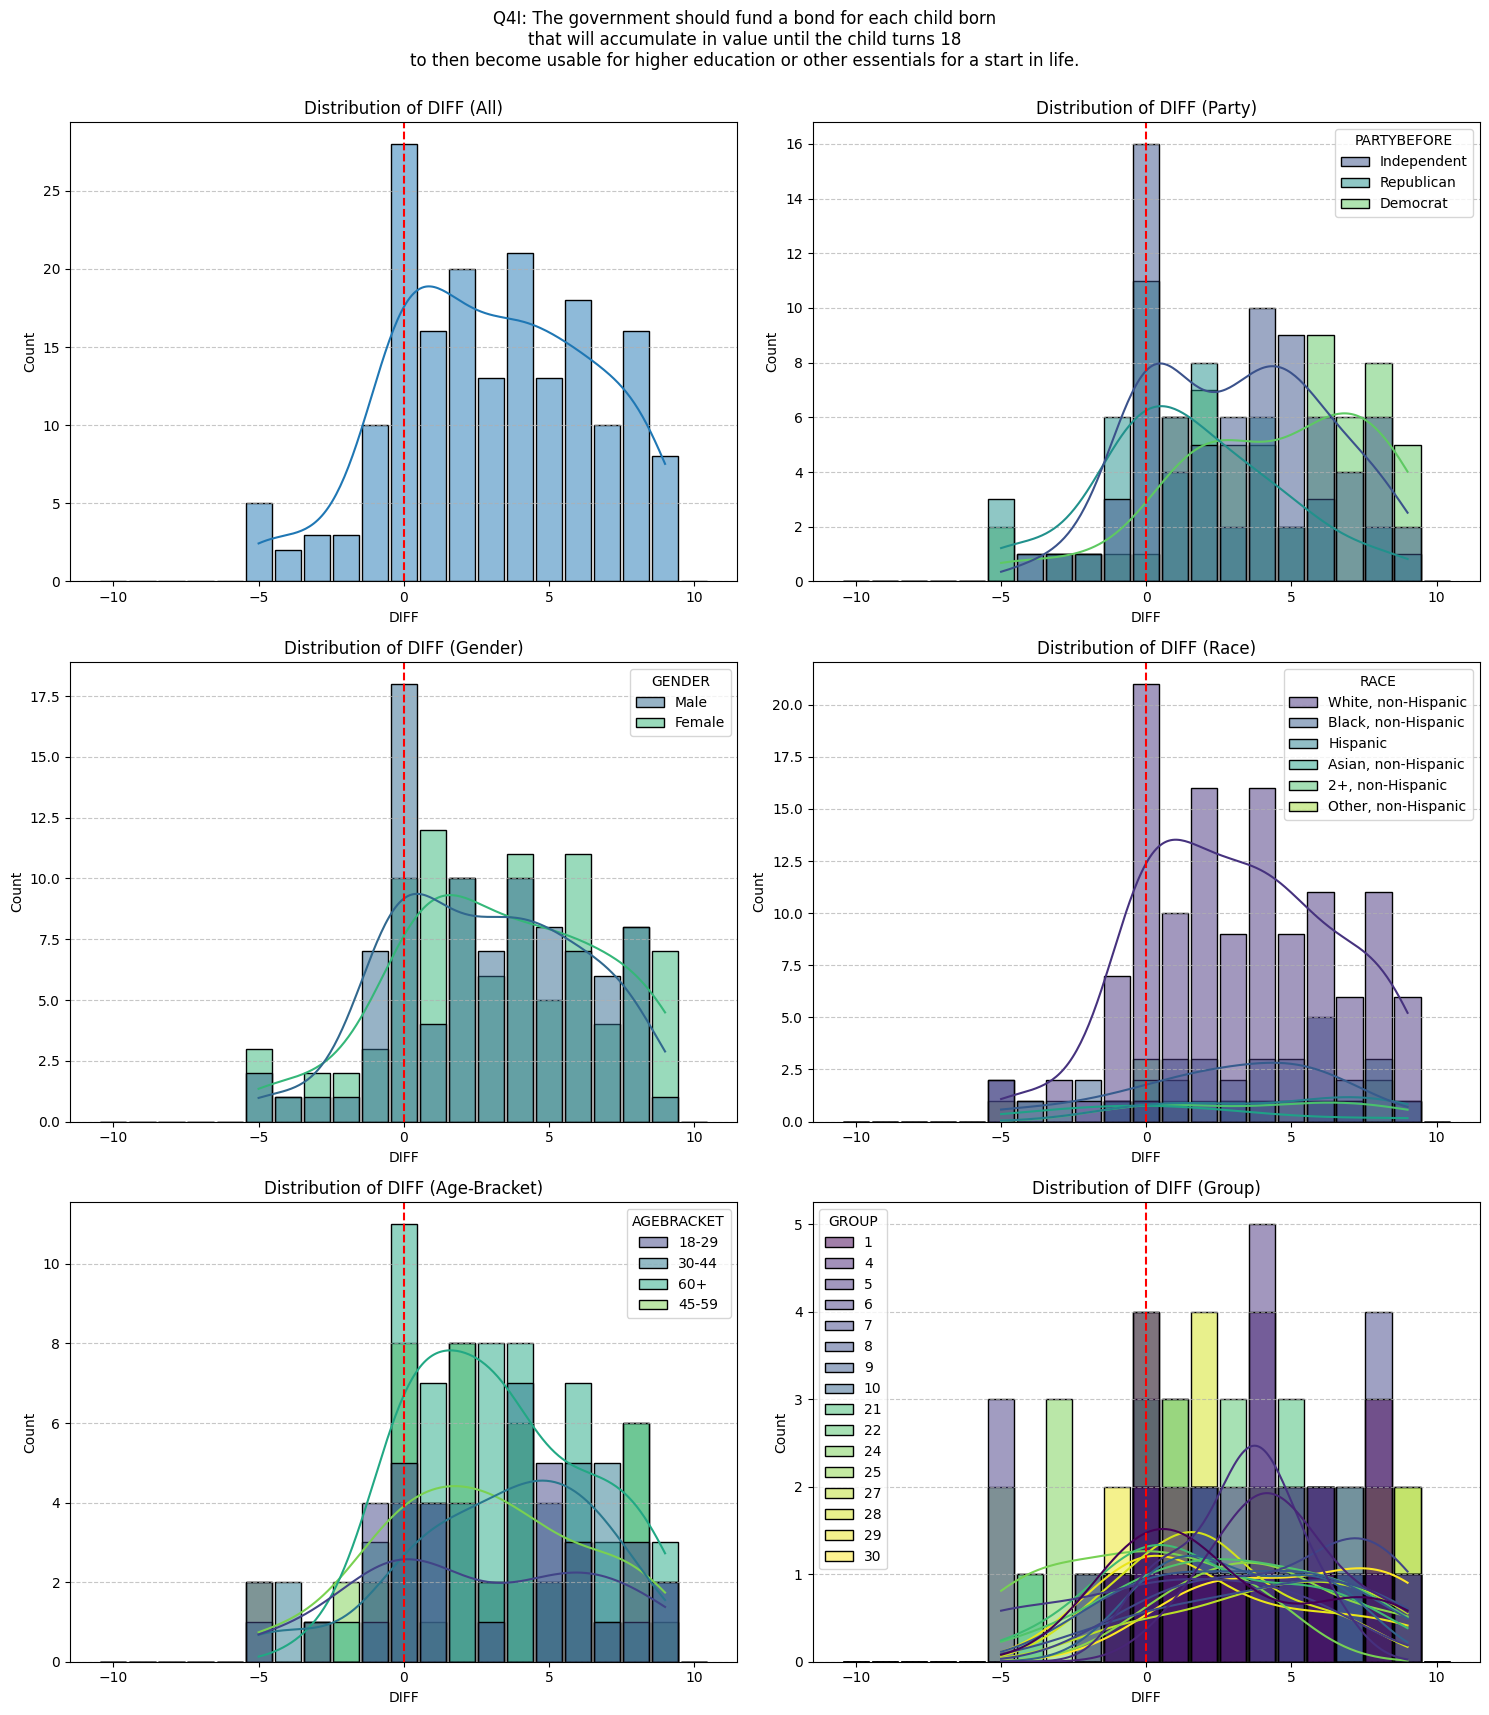

In [236]:
compare_df_Q = compare_df[compare_df["Question"] == "Q4I"]
# i want 6 plots for Q4I with different hues for demographics
fig, ax = plt.subplots(3, 2, figsize=(15, 18))

plot_dict = {"All" : (0,0), "Party" : (0,1), "Gender" : (1,0), "Race" : (1,1), "Age-Bracket" : (2,0), "Group" : (2,1)}
var_map = {"All" : "Ignore", "Party":"PARTYBEFORE", "Gender":"GENDER","Race":"RACE", "Age-Bracket":"AGEBRACKET", "Group":"GROUP"}
for plot_var, position in plot_dict.items():
    plt.sca(ax[position])
    if plot_var == "All":
        sns.histplot(data=compare_df_Q, x='DIFF', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF (All)')
    else:
        sns.histplot(data=compare_df_Q, x='DIFF', hue=var_map[plot_var], palette='viridis', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF ({plot_var})')
    plt.xlabel('DIFF')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plot red dotted line at x=0
    plt.axvline(0, color='red', linestyle='--')

fig.suptitle("Q4I: The government should fund a bond for each child born\nthat will accumulate in value until the child turns 18\nto then become usable for higher education or other essentials for a start in life.")
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

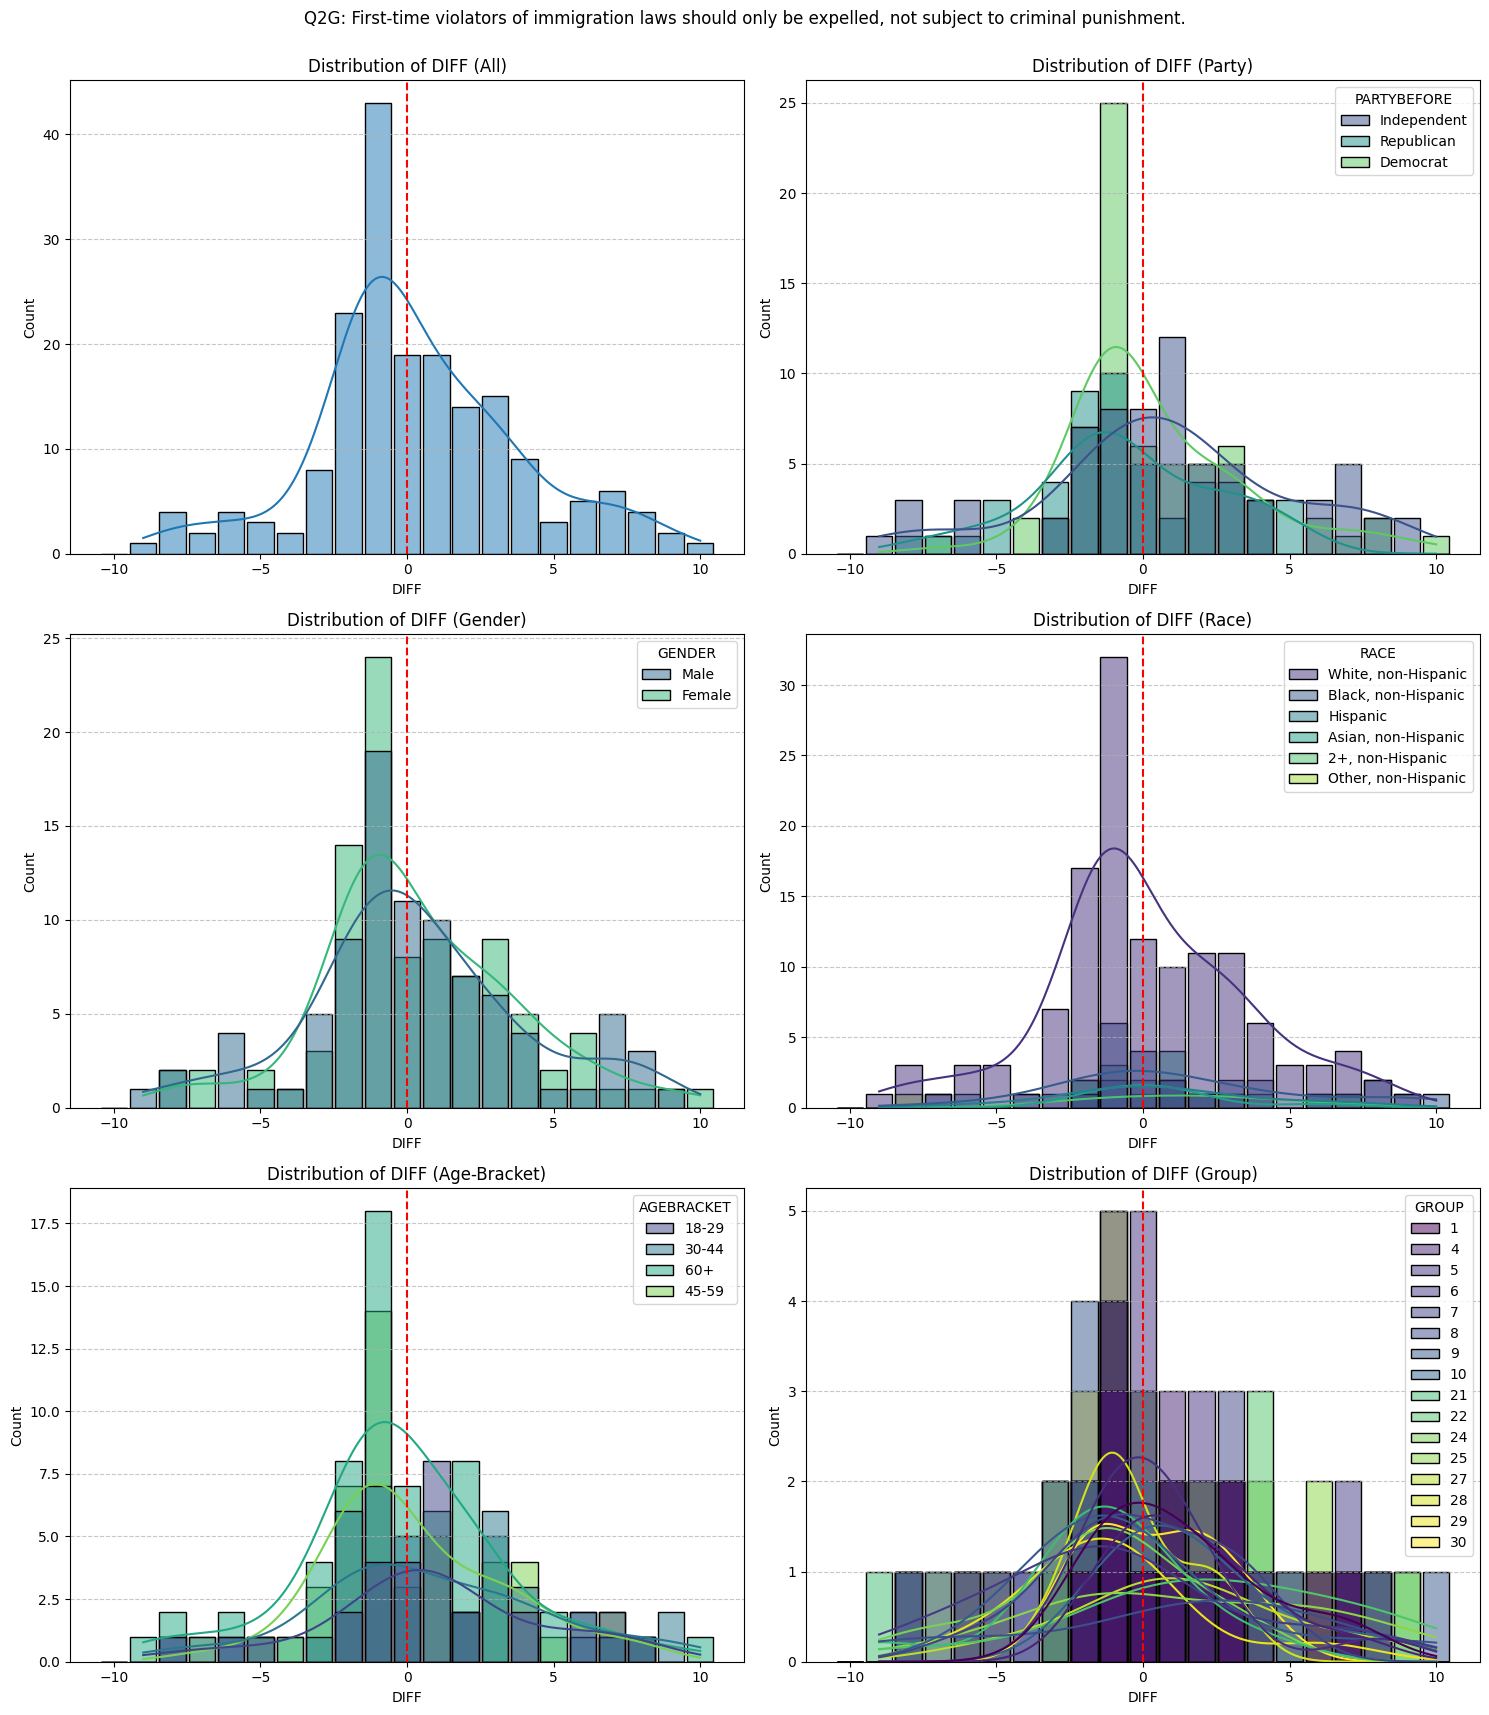

In [237]:
compare_df_Q = compare_df[compare_df["Question"] == "Q2G"]
# i want 6 plots for Q4I with different hues for demographics
fig, ax = plt.subplots(3, 2, figsize=(15, 18))

plot_dict = {"All" : (0,0), "Party" : (0,1), "Gender" : (1,0), "Race" : (1,1), "Age-Bracket" : (2,0), "Group" : (2,1)}
var_map = {"All" : "Ignore", "Party":"PARTYBEFORE", "Gender":"GENDER","Race":"RACE", "Age-Bracket":"AGEBRACKET", "Group":"GROUP"}
for plot_var, position in plot_dict.items():
    plt.sca(ax[position])
    if plot_var == "All":
        sns.histplot(data=compare_df_Q, x='DIFF', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF (All)')
    else:
        sns.histplot(data=compare_df_Q, x='DIFF', hue=var_map[plot_var], palette='viridis', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF ({plot_var})')
    plt.xlabel('DIFF')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plot red dotted line at x=0
    plt.axvline(0, color='red', linestyle='--')

fig.suptitle("Q2G: First-time violators of immigration laws should only be expelled, not subject to criminal punishment.")
plt.tight_layout(rect=[0, 0.03, 1, 0.98])